<a href="https://colab.research.google.com/github/myokota812/lecture/blob/master/pipeflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_pipe_flow(
    v_mean=0.5,
    mu=0.001,
    rho=1000,
    D=0.05,
    L=0.4
):

    """
    管内流れの速度場・速度変動・渦度を可視化する教育用モデル

    Parameters
    ----------
    v_mean : float
        平均流速 [m/s]

    mu : float
        粘性係数 [Pa s]

    rho : float
        密度 [kg/m3]

    D : float
        管径 [m]

    L : float
        観察長 [m]
    """

    # ============================================================
    # 1. 基本量
    # ============================================================

    R = D / 2.0

    nu = mu / rho

    Re = rho * v_mean * D / mu


    # ============================================================
    # 2. 格子生成
    # ============================================================

    Nz = 300
    Nr = 150

    z = np.linspace(0, L, Nz)
    r = np.linspace(-R, R, Nr)

    Z, R_grid = np.meshgrid(z, r)

    # 壁からの距離
    y = R - np.abs(R_grid)


    # ============================================================
    # 3. 流れ状態と平均速度分布
    # ============================================================

    if Re < 2300:

        # ----------------------------
        # 層流
        # ----------------------------

        regime = "Laminar"

        v_max = 2.0 * v_mean

        vz_mean = (
            v_max *
            (1.0 - (R_grid / R)**2)
        )

        turb_intensity = 0.0


    elif Re <= 4000:

        # ----------------------------
        # 遷移流
        # ----------------------------

        regime = "Transitional"

        transition = (
            (Re - 2300) /
            (4000 - 2300)
        )

        # 層流速度分布
        vz_laminar = (
            2.0 *
            v_mean *
            (1.0 - (R_grid / R)**2)
        )

        # 乱流側の速度分布
        n = 6.0

        v_max = (
            (n + 1) *
            (2 * n + 1) /
            (2 * n**2)
        ) * v_mean

        vz_turbulent = (
            v_max *
            np.clip(y / R, 1e-6, 1.0)**(1/n)
        )

        # 層流 → 乱流へ徐々に移行
        vz_mean = (
            (1 - transition) * vz_laminar
            + transition * vz_turbulent
        )

        turb_intensity = transition


    else:

        # ----------------------------
        # 乱流
        # ----------------------------

        regime = "Turbulent"

        n = (
            6.0
            + 0.5 * np.log10(Re / 4000.0)
        )

        v_max = (
            (n + 1) *
            (2 * n + 1) /
            (2 * n**2)
        ) * v_mean

        vz_mean = (
            v_max *
            np.clip(y / R, 1e-6, 1.0)**(1/n)
        )

        turb_intensity = 1.0


    # ============================================================
    # 4. 人工的な渦構造を作る
    # ============================================================

    np.random.seed(42)

    vz_fluct = np.zeros_like(Z)
    vr_fluct = np.zeros_like(Z)


    if turb_intensity > 0:

        # Reが大きいほど渦を増やす
        num_eddies = int(
            5 +
            35 * turb_intensity
        )

        for _ in range(num_eddies):

            # 渦中心
            ze = np.random.uniform(
                0,
                L
            )

            re = np.random.uniform(
                -0.85 * R,
                0.85 * R
            )

            # 渦の強さ
            gamma = (
                np.random.choice([-1, 1])
                *
                np.random.uniform(
                    0.02,
                    0.08
                )
                *
                v_mean
            )

            # 渦の大きさ
            sigma = np.random.uniform(
                0.004,
                0.010
            )

            dist_sq = (
                (Z - ze)**2
                +
                (R_grid - re)**2
            )

            # 渦の空間分布
            factor = (
                gamma /
                (
                    2 * np.pi *
                    (dist_sq + 1e-6)
                )
            ) * (
                1 -
                np.exp(
                    -dist_sq /
                    sigma**2
                )
            )

            # 軸方向速度変動
            vz_fluct += (
                -factor *
                (R_grid - re)
            )

            # 半径方向速度変動
            vr_fluct += (
                factor *
                (Z - ze)
            )

    # ============================================================
    # 5. 全速度
    # ============================================================

    vz_total = (
        vz_mean +
        turb_intensity * vz_fluct
    )

    vr_total = (
        turb_intensity * vr_fluct
    )


    # ============================================================
    # 6. 渦度
    #
    # ωθ = ∂vr/∂z - ∂vz/∂r
    # ============================================================

    dv_r_dz = np.gradient(
        vr_total,
        z,
        axis=1
    )

    dv_z_dr = np.gradient(
        vz_total,
        r,
        axis=0
    )

    vorticity = (
        dv_r_dz -
        dv_z_dr
    )


    # ============================================================
    # 7. 速度変動の大きさ
    # ============================================================

    speed_fluct = np.sqrt(
        vz_fluct**2 +
        vr_fluct**2
    )


    # ============================================================
    # 8. 描画
    # ============================================================

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12, 10),
        sharex=True
    )

    fig.suptitle(
        f"Pipe Flow Simulation | "
        f"Re = {Re:.1f} ({regime})",
        fontsize=15,
        fontweight='bold'
    )


    # ============================================================
    # 上段：速度場＋流線
    # ============================================================

    c1 = axes[0].contourf(
        Z,
        R_grid,
        vz_total,
        levels=50,
        cmap="viridis"
    )

    fig.colorbar(
        c1,
        ax=axes[0],
        label="Axial velocity $v_z$ [m/s]"
    )

    axes[0].streamplot(
        z,
        r,
        vz_total,
        vr_total,
        color="white",
        linewidth=0.8,
        density=1.5,
        arrowsize=1.2
    )

    axes[0].axhline(
        R,
        color="red",
        lw=2
    )

    axes[0].axhline(
        -R,
        color="red",
        lw=2
    )

    axes[0].set_ylabel(
        "Radial position $r$ [m]"
    )

    axes[0].set_title(
        "Velocity Field and Streamlines"
    )


    # ============================================================
    # 中段：速度変動
    # ============================================================

    c2 = axes[1].contourf(
        Z,
        R_grid,
        speed_fluct,
        levels=40,
        cmap="plasma"
    )

    fig.colorbar(
        c2,
        ax=axes[1],
        label="Fluctuation speed [m/s]"
    )

    # ベクトル表示
    skip_z = 8
    skip_r = 5

    axes[1].quiver(
        Z[
            ::skip_r,
            ::skip_z
        ],

        R_grid[
            ::skip_r,
            ::skip_z
        ],

        vz_fluct[
            ::skip_r,
            ::skip_z
        ],

        vr_fluct[
            ::skip_r,
            ::skip_z
        ],

        color="white",

        scale=0.02,

        width=0.002,

        headwidth=3
    )

    axes[1].axhline(
        R,
        color="black",
        lw=2
    )

    axes[1].axhline(
        -R,
        color="black",
        lw=2
    )

    axes[1].set_ylabel(
        "Radial position $r$ [m]"
    )

    axes[1].set_title(
        "Velocity Fluctuations and Eddy Structures"
    )


    # ============================================================
    # 下段：渦度
    # ============================================================

    vmax_vort = np.percentile(
        np.abs(vorticity),
        98
    )

    # 値がゼロの場合への対策
    if vmax_vort == 0:
        vmax_vort = 1.0

    c3 = axes[2].contourf(
        Z,
        R_grid,
        vorticity,
        levels=50,
        cmap="RdBu_r",
        vmin=-vmax_vort,
        vmax=vmax_vort
    )

    fig.colorbar(
        c3,
        ax=axes[2],
        label=r"Vorticity $\omega_\theta$ [1/s]"
    )

    axes[2].axhline(
        R,
        color="black",
        lw=2
    )

    axes[2].axhline(
        -R,
        color="black",
        lw=2
    )

    axes[2].set_xlabel(
        "Axial position $z$ [m]"
    )

    axes[2].set_ylabel(
        "Radial position $r$ [m]"
    )

    axes[2].set_title(
        "Vorticity "
        "(red: positive, blue: negative)"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    plt.show()


# ================================================================
# 実行例
# ================================================================

simulate_pipe_flow(
    v_mean=0.0042,
    mu=0.0001,
    rho=1000,
    D=0.05
)

NameError: name 'Re' is not defined

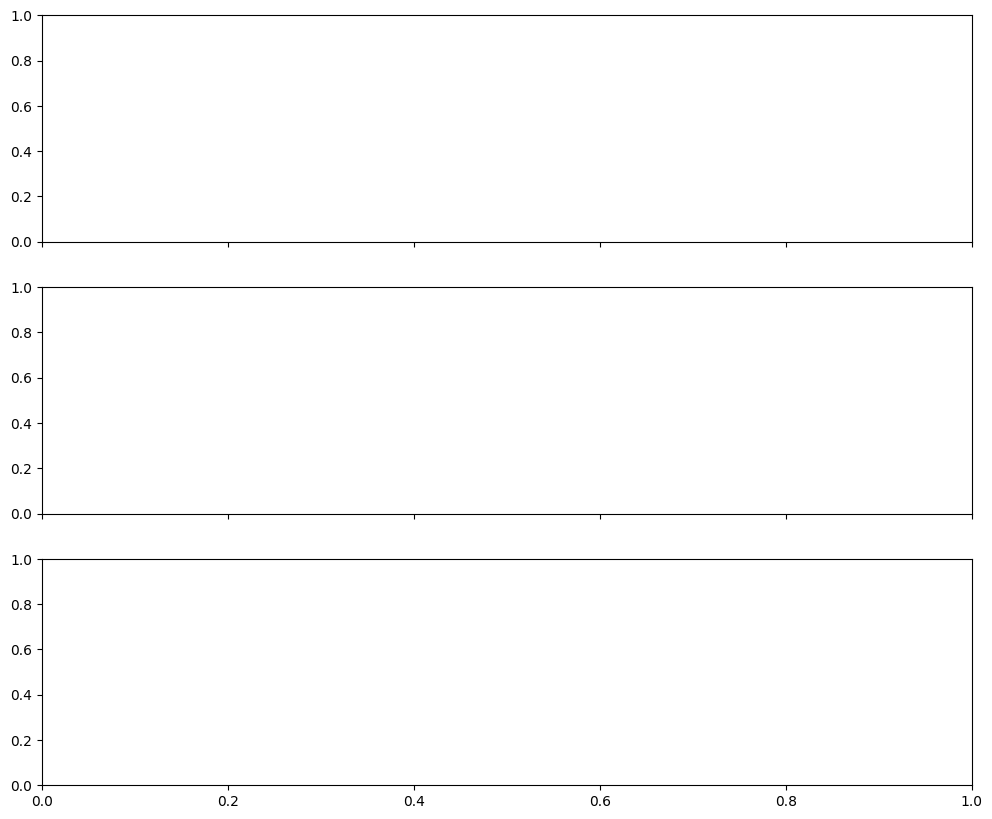

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_pipe_flow(v_mean=0.5, mu=0.001, rho=1000, D=0.05, L=0.4):
    """
    パラメータに応じて層流・遷移流・乱流の速度場と渦度場を計算・可視化する関数

    パラメータ:
    - v_mean: 平均流速 [m/s]
    - mu: 粘性係数 [Pa·s] (水: 0.001, 水飴/オイル: > 0.1)
    - rho: 密度 [kg/m³] (水: 1000)
    - D: 管径 [m]
    - L: 観察長 [m]
    """
    R = D / 2.0
    nu = mu / rho                  # 動粘性係数 [m²/s]
    Re = (rho * v_mean * D) / mu   # レイノルズ数

    # 格子生成
    Nz, Nr = 300, 150
    z = np.linspace(0, L, Nz)
    r = np.linspace(-R, R, Nr)
    Z, R_grid = np.meshgrid(z, r)
    y = R - np.abs(R_grid)          # 壁からの距離

    # 状態の判定と物理モデルの設定
    if Re < 2300:
        regime = "Laminar"
        v_max = 2.0 * v_mean
        vz_mean = v_max * (1.0 - (R_grid / R)**2)
        turb_intensity = 0.0
    elif Re <= 4000:
        regime = "Transitional"
        # 層流と乱流の中間（1/6乗法則＋軽微なゆらぎ）
        v_max = 1.25 * v_mean
        vz_mean = v_max * np.clip(y / R, 1e-6, 1.0)**(1/6.0)
        turb_intensity = 0.05 * (Re - 2300) / (4000 - 2300)
    else:
        regime = "Turbulent"
        # Reの大きさに応じてべき乗指数 n を調整 (Reが大きいほど壁際が急激になる)
        n = 6.0 + 0.5 * np.log10(Re / 4000.0)
        v_max = ((n + 1) * (2 * n + 1) / (2 * n**2)) * v_mean
        vz_mean = v_max * np.clip(y / R, 1e-6, 1.0)**(1/n)
        turb_intensity = 0.12

    # 渦揺らぎの重畳 (遷移域・乱流の場合)
    np.random.seed(42)
    vz_fluct = np.zeros_like(Z)
    vr_fluct = np.zeros_like(Z)

    if turb_intensity > 0:
        num_eddies = int(50 + turb_intensity * 500)
        for _ in range(num_eddies):
            ze = np.random.uniform(0, L)
            re = np.random.uniform(-R * 0.85, R * 0.85)
            gamma = (np.random.choice([-1, 1])* np.random.uniform(0.02, 0.08)* v_mean)
            sigma = np.random.uniform(0.004, 0.010)

            dist_sq = (Z - ze)**2 + (R_grid - re)**2
            factor = (gamma / (2 * np.pi * (dist_sq + 1e-6))) * (1 - np.exp(-dist_sq / sigma**2))
            vz_fluct += -factor * (R_grid - re)
            vr_fluct +=  factor * (Z - ze)

    vz_total = vz_mean + vz_fluct
    vr_total = vr_fluct

    # 渦度の計算 ω_theta = dv_r/dz - dv_z/dr
    dv_r_dz = np.gradient(vr_total, z, axis=1)
    dv_z_dr = np.gradient(vz_total, r, axis=0)
    vorticity = dv_r_dz - dv_z_dr

    # --- 描画 ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

fig.suptitle(
    f"Pipe Flow Simulation | Re = {Re:.1f} ({regime})",
    fontsize=15,
    fontweight='bold'
)

# ============================================================
# 1. 主流速度 + 流線
# ============================================================

c1 = axes[0].contourf(
    Z, R_grid, vz_total,
    levels=50,
    cmap='viridis'
)

fig.colorbar(
    c1,
    ax=axes[0],
    label='Axial velocity $v_z$ [m/s]'
)

# 流線
axes[0].streamplot(
    z,
    r,
    vz_total,
    vr_total,
    color='white',
    linewidth=0.8,
    density=1.5,
    arrowsize=1.2
)

# 壁
axes[0].axhline(R, color='red', lw=2)
axes[0].axhline(-R, color='red', lw=2)

axes[0].set_ylabel('Radial position $r$ [m]')
axes[0].set_title('Velocity field and streamlines')


# ============================================================
# 2. 速度変動成分
# ============================================================

speed_fluct = np.sqrt(
    vz_fluct**2 + vr_fluct**2
)

c2 = axes[1].contourf(
    Z,
    R_grid,
    speed_fluct,
    levels=40,
    cmap='plasma'
)

fig.colorbar(
    c2,
    ax=axes[1],
    label='Fluctuation speed [m/s]'
)

# 渦による速度ベクトル
skip_z = 8
skip_r = 5

axes[1].quiver(
    Z[::skip_r, ::skip_z],
    R_grid[::skip_r, ::skip_z],
    vz_fluct[::skip_r, ::skip_z],
    vr_fluct[::skip_r, ::skip_z],
    color='white',
    scale=0.02,
    width=0.002,
    headwidth=3
)

axes[1].axhline(R, color='black', lw=2)
axes[1].axhline(-R, color='black', lw=2)

axes[1].set_ylabel('Radial position $r$ [m]')
axes[1].set_title('Turbulent velocity fluctuations')


# ============================================================
# 3. 渦度
# ============================================================

vmax_vort = np.percentile(
    np.abs(vorticity),
    98
)

c3 = axes[2].contourf(
    Z,
    R_grid,
    vorticity,
    levels=50,
    cmap='RdBu_r',
    vmin=-vmax_vort,
    vmax=vmax_vort
)

fig.colorbar(
    c3,
    ax=axes[2],
    label=r'Vorticity $\omega_\theta$ [1/s]'
)

axes[2].axhline(R, color='black', lw=2)
axes[2].axhline(-R, color='black', lw=2)

axes[2].set_xlabel('Axial position $z$ [m]')
axes[2].set_ylabel('Radial position $r$ [m]')
axes[2].set_title(
    'Vorticity '
    '(red: positive, blue: negative)'
)

plt.tight_layout()
plt.show()


# --- 実行例 ---
simulate_pipe_flow(v_mean=0.0047, mu=0.0001, rho=1000, D=0.05)

# 水（粘度小）で低速（層流）: Re ≈ 500
#simulate_pipe_flow(v_mean=0.01, mu=0.001, rho=1000, D=0.05)

# 水（粘度小）で高速（乱流）: Re ≈ 25000
#simulate_pipe_flow(v_mean=0.5, mu=0.001, rho=1000, D=0.05)

# 高粘度オイル（粘度大）で中速（層流）: Re ≈ 50
#simulate_pipe_flow(v_mean=0.5, mu=0.5, rho=900, D=0.05)

<>:68: SyntaxWarning: invalid escape sequence '\('
<>:80: SyntaxWarning: invalid escape sequence '\('
<>:81: SyntaxWarning: invalid escape sequence '\('
<>:68: SyntaxWarning: invalid escape sequence '\('
<>:80: SyntaxWarning: invalid escape sequence '\('
<>:81: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_37284/269273300.py:68: SyntaxWarning: invalid escape sequence '\('
  cbar.set_label('Vorticity \(\omega_\\theta\) [1/s]', fontsize=11)
/tmp/ipykernel_37284/269273300.py:80: SyntaxWarning: invalid escape sequence '\('
  ax.set_xlabel('Axial Position \(z\) [m]', fontsize=11)
/tmp/ipykernel_37284/269273300.py:81: SyntaxWarning: invalid escape sequence '\('
  ax.set_ylabel('Radial Position \(r\) [m]', fontsize=11)


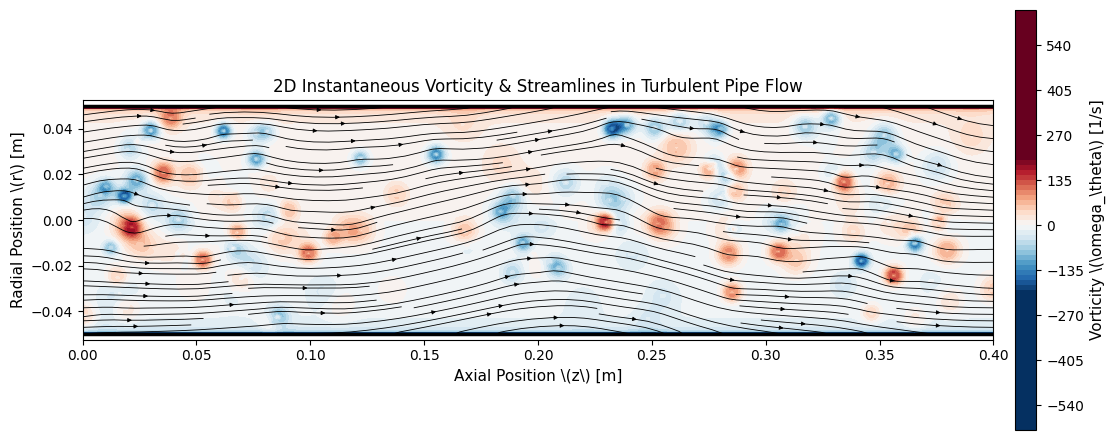

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 計算領域とグリッドの設定 ---
R = 0.05        # 円管半径 [m] (5cm)
L = 0.4         # 観察する管の長さ [m] (40cm)

Nz = 400        # 流れ方向 (z) の格子数
Nr = 200        # 径方向 (r) の格子数

z = np.linspace(0, L, Nz)
r = np.linspace(-R, R, Nr)
Z, R_grid = np.meshgrid(z, r)

# --- 2. 平均流れ場（Turbulent Mean Flow）の計算 ---
v_max = 1.0     # 中心最大速度 [m/s]
n = 7           # 1/7乗法則

# 壁からの距離 y
y = R - np.abs(R_grid)
y = np.maximum(y, 1e-6) # ゼロ割防止

# 軸方向平均速度 vz_mean
vz_mean = v_max * (y / R)**(1/n)

# --- 3. 乱流の微細な渦揺らぎの合成 (Pseudo-Turbulent Eddies) ---
np.random.seed(2026)
num_eddies = 150  # 生成する微小渦の数

# 渦のゆらぎ速度成分
vz_fluct = np.zeros_like(Z)
vr_fluct = np.zeros_like(Z)

# ランダムな渦の位置と強度を生成（壁付近に多めに配置）
for _ in range(num_eddies):
    ze = np.random.uniform(0, L)
    re = np.random.uniform(-R * 0.9, R * 0.9)
    gamma = np.random.choice([-1, 1]) * np.random.uniform(0.002, 0.008) # 渦の強度
    sigma = np.random.uniform(0.003, 0.008)                             # 渦のサイズ

    # 渦による速度場（Oseen-Lamb渦モデル）
    dist_sq = (Z - ze)**2 + (R_grid - re)**2
    factor = (gamma / (2 * np.pi * (dist_sq + 1e-6))) * (1 - np.exp(-dist_sq / sigma**2))

    vz_fluct += -factor * (R_grid - re)
    vr_fluct +=  factor * (Z - ze)

# 全速度場 (平均 + 揺らぎ)
vz_total = vz_mean + vz_fluct
vr_total = vr_fluct

# --- 4. 渦度（Vorticity）の計算 ---
# 2D軸対称平面における渦度 ω_theta = dv_r/dz - dv_z/dr
dv_r_dz = np.gradient(vr_total, z, axis=1)
dv_z_dr = np.gradient(vz_total, r, axis=0)
vorticity = dv_r_dz - dv_z_dr

# --- 5. プロット描画 ---
fig, ax = plt.subplots(figsize=(12, 4.5))

# (A) 渦度コンター（カラーマップ）
# 対数的な視認性を高めるため、対称対数（symlog）または適切な範囲でクリッピング
vmax_val = np.percentile(np.abs(vorticity), 98)
contour = ax.contourf(Z, R_grid, vorticity, levels=100, cmap='RdBu_r',
                     vmin=-vmax_val, vmax=vmax_val)

cbar = fig.colorbar(contour, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Vorticity \(\omega_\\theta\) [1/s]', fontsize=11)

# (B) 流線（Streamlines）の重ね描き
# densityで流線の密度、colorで視認性を調整
ax.streamplot(z, r, vz_total, vr_total, color='black', linewidth=0.6,
              density=(1.5, 1.2), arrowsize=0.6)

# 管の壁面を描画
ax.axhline(R, color='black', linewidth=2.5)
ax.axhline(-R, color='black', linewidth=2.5)

# 軸とタイトルの設定
ax.set_xlabel('Axial Position \(z\) [m]', fontsize=11)
ax.set_ylabel('Radial Position \(r\) [m]', fontsize=11)
ax.set_title('2D Instantaneous Vorticity & Streamlines in Turbulent Pipe Flow', fontsize=12)
ax.set_ylim(-R*1.05, R*1.05)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()